In [11]:
import os
from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import FAISS
from langgraph.graph import StateGraph, END, START
from langchain_core.messages import HumanMessage, AIMessage,SystemMessage
from typing import TypedDict, List
from IPython.display import Image, display

In [12]:
# 1. Load API key from .env
load_dotenv()

# 2. Create embeddings
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# 3. Load the saved vectorstore
vectorstore = FAISS.load_local(
    "vectorstore",                    # folder name
    embeddings,                    # embeddings variable
    allow_dangerous_deserialization=True  # True or False
)

# 4. Create LLM
llm = ChatOpenAI(model="gpt-4o-mini")

# 5. Print to confirm it loaded
print("Vectorstore loaded!")

Vectorstore loaded!


In [23]:
# Define what information the agent carries at each step
class AgentState(TypedDict):
    messages: List # conversation history
    retrieved_docs: str # chunks fetched from vectorstore

def retrieve_node(state: AgentState):
    # Get the last message from user
    query=state["messages"][-1].content

    # Search vectorstore for relevant chunks
    result=vectorstore.similarity_search(query, k=3)

    # Join all chunks into one string
    retrieved_docs="\n\n.join([docs.pages_content for doc in results])"
    
    # Return updated state
    return{"retrieved_docs":retrieved_docs}



In [24]:
def respond_node(state: AgentState):
    # Get conversation history
    messages = state['messages']

    # Get retrieved chunks
    retrieved_docs = state['retrieved_docs']

    # Create system prompt
    prompt = [
        SystemMessage(content=f"""
        You are a personal financial advisor for Indian users.
        Use the following information to answer the question:
        {retrieved_docs}
        Give specific, simple, actionable advice.
        """)]
    
    # prompt is already a list so just add messages directly
    response = llm.invoke(prompt + messages)

    return {"messages": messages + [AIMessage(content=response.content)]}

In [25]:
# Create the graph
graph = StateGraph(AgentState)

# Add nodes
graph.add_node("retrieve", retrieve_node)
graph.add_node("respond", respond_node)

# Connect nodes in order
graph.add_edge(START, "retrieve")
graph.add_edge("retrieve","respond")
graph.add_edge("respond", END)

# Set starting node
graph.set_entry_point("retrieve")

# Compile
agent = graph.compile()

print("Agent is ready!")

Agent is ready!


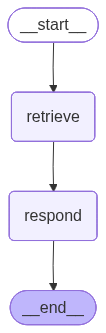

In [16]:
display(Image(agent.get_graph().draw_mermaid_png()))

In [26]:
# Test the agent with a question
result = agent.invoke({
    "messages": [HumanMessage(content="What is SIP?")],
    "retrieved_docs": ""
})

# Print the final answer
print(result["messages"][-1].content)

SIP, or Systematic Investment Plan, is a method of investing in mutual funds in a disciplined manner. Instead of investing a lump sum amount, SIP allows you to invest a fixed amount of money at regular intervals (monthly, quarterly, etc.). Here’s how it works and why you might consider it:

### How SIP Works:
1. **Fixed Amount**: You decide how much you want to invest regularly (e.g., ₹1,000 per month).
2. **Automatic Deductions**: The amount is automatically deducted from your bank account on the chosen date.
3. **Units Purchased**: The money is used to purchase units of the mutual fund on the basis of the prevailing Net Asset Value (NAV).
4. **Compounding Benefits**: By investing regularly, you benefit from rupee-cost averaging, as you buy more units when prices are low and fewer when prices are high.

### Benefits of SIP:
- **Disciplined Investing**: Helps in building a habit of saving and investing regularly.
- **Flexibility**: You can start with a small amount and increase it as y